In [1]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.metrics import accuracy_score, roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix

# Generate dataset

In [17]:
X, y = make_classification( n_samples=2502,
                            random_state=259202,
                            n_features=2,
                            n_informative=2,
                            n_redundant=0,
                            n_repeated=0,
                            class_sep=2)
Xm, ym = make_moons(n_samples=2502, random_state=259202, noise=0.1)
Xb ,yb = make_blobs(n_samples=2502, random_state=259202, n_features=2, centers=5, cluster_std=0.8)

In [18]:
X.shape, y.shape, Xm.shape, ym.shape, Xb.shape, yb.shape

((2502, 2), (2502,), (2502, 2), (2502,), (2502, 2), (2502,))

In [19]:
print(set(yb))
yb = np.where(yb < 3, 0, 1)
print(set(yb))

{0, 1, 2, 3, 4}
{0, 1}


In [20]:
def plot_data(X, y, title=""):
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
    plt.title(title)
    plt.show()

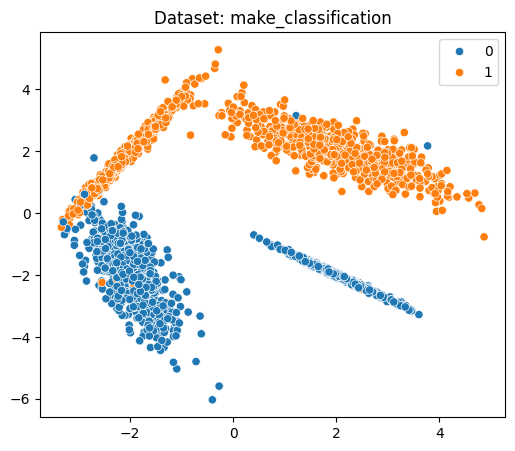

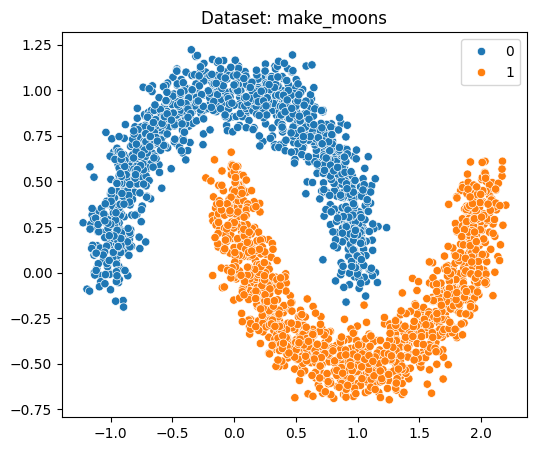

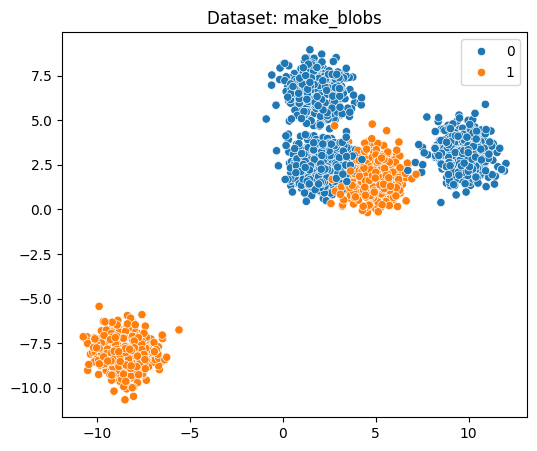

In [21]:
plot_data(X,y,"Dataset: make_classification")
plot_data(Xm,ym,"Dataset: make_moons")
plot_data(Xb,yb,"Dataset: make_blobs")

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=295202)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, random_state=295202)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, random_state=295202)

In [38]:
def plot_decision_boundary(X, y, model, title=""):
    h = 0.02
    x_min, x_max = X[:,0].min(), X[:,0].max()
    y_min, y_max = X[:,1].min(), X[:,1].max()
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    pts = np.c_[xx.ravel(), yy.ravel()]
    
    Z = model.predict(pts)
    
    Z = Z.reshape(xx.shape)
    
    # decition boundary
    plt.contourf(xx, yy, Z, alpha=0.3)
    
    # decision line
    plt.contour(xx, yy, Z, colors='k', linewidths=1)
    
    scatter = plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
    
    plt.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
    plt.title(title)
    plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.show()